# first test

In [73]:
# !python -m pip install seaborn

In [74]:
import pandas as pd
import numpy as np  # ← add this
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder


In [75]:
df = pd.read_csv('train.csv')

In [76]:
df = df.rename(columns={'X1': 'item_Identifier', 'X2': 'item_Weight', 'X3': 'item_Fat_Content', 'X4': 'item_Visibility', 'X5': 'item_Type', 'X6': 'item_MRP', 'X7': 'outlet_Identifier', 'X8': 'outlet_Establishment_Year', 'X9': 'outlet_Size', 'X10': 'outlet_Location_Tier', 'X11': 'outlet_Type'})

In [77]:
df.head()

,item_Identifier,item_Weight,item_Fat_Content,item_Visibility,item_Type,item_MRP,outlet_Identifier,outlet_Establishment_Year,outlet_Size,outlet_Location_Tier,outlet_Type,Y
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.23
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.09
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.65
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,6.60
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.90


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_Identifier            6000 non-null   str    
 1   item_Weight                4994 non-null   float64
 2   item_Fat_Content           6000 non-null   str    
 3   item_Visibility            6000 non-null   float64
 4   item_Type                  6000 non-null   str    
 5   item_MRP                   6000 non-null   float64
 6   outlet_Identifier          6000 non-null   str    
 7   outlet_Establishment_Year  6000 non-null   int64  
 8   outlet_Size                4289 non-null   str    
 9   outlet_Location_Tier       6000 non-null   str    
 10  outlet_Type                6000 non-null   str    
 11  Y                          6000 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 562.6 KB


In [79]:
df.describe(include='all')

,item_Identifier,item_Weight,item_Fat_Content,item_Visibility,item_Type,item_MRP,outlet_Identifier,outlet_Establishment_Year,outlet_Size,outlet_Location_Tier,outlet_Type,Y
count,6000,4994.000000,6000,6000.000000,6000,6000.000000,6000,6000.000000,4289,6000,6000,6000.000000
unique,1553,NaN,5,NaN,16,NaN,10,NaN,3,3,4,NaN
top,FDP28,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,OUT045,NaN,Medium,Tier 3,Supermarket Type1,NaN
freq,8,NaN,3595,NaN,875,NaN,677,NaN,1935,2358,3967,NaN
mean,NaN,12.956536,NaN,0.066333,NaN,141.228200,NaN,1997.840333,NaN,NaN,NaN,7.303403
std,NaN,4.658851,NaN,0.051492,NaN,62.540569,NaN,8.334412,NaN,NaN,NaN,1.014361
min,NaN,4.555000,NaN,0.000000,NaN,31.290000,NaN,1985.000000,NaN,NaN,NaN,3.510000
25%,NaN,8.895000,NaN,0.027030,NaN,94.037650,NaN,1987.000000,NaN,NaN,NaN,6.750000
50%,NaN,12.800000,NaN,0.054620,NaN,143.197000,NaN,1999.000000,NaN,NaN,NaN,7.500000
75%,NaN,17.100000,NaN,0.095154,NaN,186.522050,NaN,2004.000000,NaN,NaN,NaN,8.040000


In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
df.nunique()

item_Identifier              1553
item_Weight                   410
item_Fat_Content                5
item_Visibility              5577
item_Type                      16
item_MRP                     4634
outlet_Identifier              10
outlet_Establishment_Year       9
outlet_Size                     3
outlet_Location_Tier            3
outlet_Type                     4
Y                             508
dtype: int64

In [82]:
item_fat_content = df['item_Fat_Content'].unique()
print(f"unique values in item_Fat_Content : {item_fat_content} \n")
item_type = df['item_Type'].unique()
print(f"unique values in item_Type : {item_type} \n")
outlet_identifier = df['outlet_Identifier'].unique()
print(f"unique values in outlet_Identifier : {outlet_identifier} \n")
outlet_establishment_year = df['outlet_Establishment_Year'].unique()
print(f"unique values in outlet_Establishment_Year : {outlet_establishment_year} \n")
outlet_size = df['outlet_Size'].unique()
print(f"unique values in outlet_Size : {outlet_size} \n")
outlet_location_tier = df['outlet_Location_Tier'].unique()
print(f"unique values in outlet_Location_Tier : {outlet_location_tier} \n")
outlet_type = df['outlet_Type'].unique()
print(f"unique values in outlet_Type : {outlet_type} \n")

unique values in item_Fat_Content : <StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str 

unique values in item_Type : <StringArray>
[                'Dairy',           'Soft Drinks',                  'Meat',
 'Fruits and Vegetables',             'Household',          'Baking Goods',
           'Snack Foods',          'Frozen Foods',             'Breakfast',
    'Health and Hygiene',           'Hard Drinks',                'Canned',
                'Breads',         'Starchy Foods',                'Others',
               'Seafood']
Length: 16, dtype: str 

unique values in outlet_Identifier : <StringArray>
['OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027', 'OUT045', 'OUT017',
 'OUT046', 'OUT035', 'OUT019']
Length: 10, dtype: str 

unique values in outlet_Establishment_Year : [1999 2009 1998 1987 1985 2002 2007 1997 2004] 

unique values in outlet_Size : <StringArray>
['Medium', nan, 'High', 'Small']
Length: 4, dtype: str 

unique values in outlet_Locatio

In [83]:
x = df["item_Weight"].mean()

df.fillna({"item_Weight": x}, inplace=True)
df.fillna({"outlet_Size": "Medium"}, inplace=True)

,item_Identifier,item_Weight,item_Fat_Content,item_Visibility,item_Type,item_MRP,outlet_Identifier,outlet_Establishment_Year,outlet_Size,outlet_Location_Tier,outlet_Type,Y
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.23
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.09
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.65
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,6.60
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.90
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,FDB32,20.600,Low Fat,0.023586,Fruits and Vegetables,94.7778,OUT017,2007,Medium,Tier 2,Supermarket Type1,7.18
5996,FDJ16,9.195,Low Fat,0.115064,Frozen Foods,58.6246,OUT049,1999,Medium,Tier 1,Supermarket Type1,6.77
5997,FDJ32,10.695,Low Fat,0.057910,Fruits and Vegetables,60.4536,OUT045,2002,Medium,Tier 2,Supermarket Type1,5.21
5998,FDO12,15.750,Low Fat,0.054920,Baking Goods,195.8452,OUT035,2004,Small,Tier 2,Supermarket Type1,8.50


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_Identifier            6000 non-null   str    
 1   item_Weight                6000 non-null   float64
 2   item_Fat_Content           6000 non-null   str    
 3   item_Visibility            6000 non-null   float64
 4   item_Type                  6000 non-null   str    
 5   item_MRP                   6000 non-null   float64
 6   outlet_Identifier          6000 non-null   str    
 7   outlet_Establishment_Year  6000 non-null   int64  
 8   outlet_Size                6000 non-null   str    
 9   outlet_Location_Tier       6000 non-null   str    
 10  outlet_Type                6000 non-null   str    
 11  Y                          6000 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 562.6 KB


In [85]:
df.head()

,item_Identifier,item_Weight,item_Fat_Content,item_Visibility,item_Type,item_MRP,outlet_Identifier,outlet_Establishment_Year,outlet_Size,outlet_Location_Tier,outlet_Type,Y
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.23
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.09
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,7.65
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,6.60
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,6.90


In [ ]:
for x in df.index:
  if df.loc[x, "item_Fat_Content"] =="low fat" or df.loc[x, "item_Fat_Content"] =="LF":
    df.loc[x, "item_Fat_Content"] = "Low Fat"
  elif df.loc[x, "item_Fat_Content"] =="reg":
    df.loc[x, "item_Fat_Content"] = "Regular"

In [87]:
x3 = df['item_Fat_Content'].unique() 
print(f"unique values in item_Fat_Content : {x3} \n")

unique values in item_Fat_Content : <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str 



LOW FAT AND REGULAR

In [88]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['item_Fat_Content']                            # Mean Squared Error: 0.41947350359700525

le = LabelEncoder()                                   
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [89]:
#df = pd.get_dummies(df, columns=['item_Weight'], drop_first=True) #Mean Squared Error: 0.4427000828512708

In [90]:
x=df.drop(columns=['Y'])
y=df['Y']

x=pd.get_dummies(x)
x=x.fillna(x.mean())

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train , X_test , y_train ,y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

RMSE: 0.6494
Mean Squared Error: 0.20770059114928918


Convert years to age

In [92]:
# Convert Establishment Year Ã¢â€ â€™ Outlet Age (more meaningful)
df['outlet_Age'] = 2026 - df['outlet_Establishment_Year']

# Fix Item Visibility zeros (0 visibility is likely a data error)
df['item_Visibility'] = df['item_Visibility'].replace(0, df['item_Visibility'].mean())

In [93]:
df.drop(['item_Identifier', 'outlet_Identifier' , 'outlet_Establishment_Year'], axis=1, inplace=True)

Encoding Tiers

In [94]:
tier_map = {'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1}
df['outlet_Location_Tier'] = df['outlet_Location_Tier'].map(tier_map)

# Result: 'Tier 1' = 3 (highest), 'Tier 2' = 2, 'Tier 3' = 1 (lowest)
print(df['outlet_Location_Tier'].value_counts())

outlet_Location_Tier
1    2358
2    1992
3    1650
Name: count, dtype: int64


In [95]:
df.head()

,item_Weight,item_Fat_Content,item_Visibility,item_Type,item_MRP,outlet_Size,outlet_Location_Tier,outlet_Type,Y,item_Type_cat,item_MRP_log,outlet_Age
0,9.30,0,0.016047,Dairy,249.8092,Medium,3,Supermarket Type1,8.23,FD,5.524692,27
1,5.92,1,0.019278,Soft Drinks,48.2692,Medium,1,Supermarket Type2,6.09,DR,3.897299,17
2,17.50,0,0.016760,Meat,141.6180,Medium,3,Supermarket Type1,7.65,FD,4.960170,27
3,19.20,1,0.066333,Fruits and Vegetables,182.0950,Medium,1,Grocery Store,6.60,FD,5.210005,28
4,8.93,0,0.066333,Household,53.8614,High,1,Supermarket Type1,6.90,NC,4.004810,39


correlation

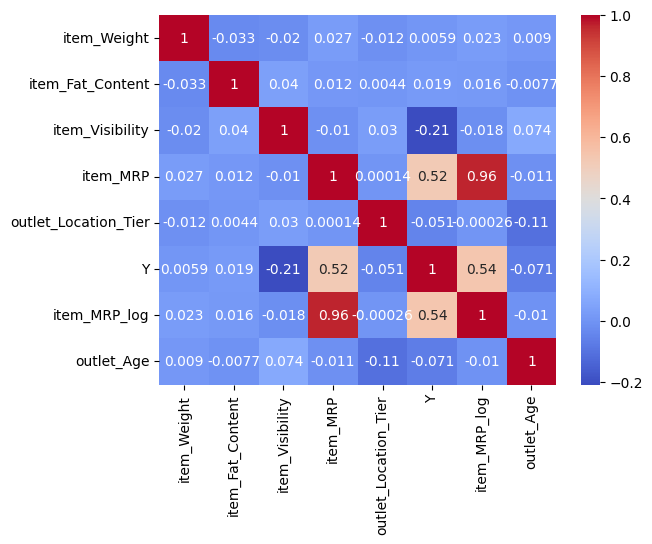

Mean Squared Error: 0.20770059114928918


In [96]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()
# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse) 

In [97]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
print("RMSE:", mse ** 0.5)

MSE: 0.20770059114928918
RMSE: 0.455741803161932


In [ ]:
test_df = pd.read_csv('test.csv')

test_df = test_df.rename(columns={
    'X1': 'item_Identifier', 'X2': 'item_Weight', 'X3': 'item_Fat_Content',
    'X4': 'item_Visibility',  'X5': 'item_Type',   'X6': 'item_MRP',
    'X7': 'outlet_Identifier', 'X8': 'outlet_Establishment_Year',
    'X9': 'outlet_Size',      'X10': 'outlet_Location_Tier', 'X11': 'outlet_Type'
})

# Fill missing values using the same mean from train
train_weight_mean = df['item_Weight'].mean()
test_df.fillna({'item_Weight': train_weight_mean, 'outlet_Size': 'Medium'}, inplace=True)        #TODO might need some changes later

# Standardise fat content labels
test_df['item_Fat_Content'] = test_df['item_Fat_Content'].replace({
    'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'
})

# Feature engineering (same as train)
test_df['outlet_Age'] = 2026 - test_df['outlet_Establishment_Year']
test_df['item_Visibility'] = test_df['item_Visibility'].replace(
    0, test_df['item_Visibility'].mean()
)

test_df.drop(['item_Identifier', 'outlet_Identifier', 'outlet_Establishment_Year'], axis=1, inplace=True)

# Encode fat content and tiers
test_df['item_Fat_Content'] = le.transform(test_df['item_Fat_Content'])
test_df['outlet_Location_Tier'] = test_df['outlet_Location_Tier'].map(tier_map)



In [101]:
X_submit = pd.get_dummies(test_df)
X_submit = X_submit.reindex(columns=x.columns, fill_value=0)
X_submit = X_submit.fillna(X_submit.mean())

test_preds = model.predict(X_submit)

In [102]:
submission = pd.read_csv('sample_submission.csv')
submission['Y'] = test_preds
submission.to_csv('sample_submission.csv', index=False)

print("Saved! Preview:")
submission.head()

Saved! Preview:


,row_id,Y
0,0,4.911667
1,1,5.566658
2,2,3.940012
3,3,5.412993
4,4,5.652528
